# Module 7 — Tropospheric Photochemistry and the Hydroxyl Radical
### B4 Chemistry in the Atmosphere · companion notebook

Reproduces the steady-state [OH]/[HO2] derivation from Sec 2.5.1, solves Example 2 (tropical
boundary layer OH), and checks the square-root [HOx] vs J(O1D) scaling from Fig 2.5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['font.size'] = 11

## Reproducing the mid-latitude steady state (Sec 2.5.1)

Production of OH: ~10% of O(1D) formed reacts with H2O to give 2 OH.
Loss of OH: dominated by OH + CO -> CO2 + H (R2.7).
Loss of HO2: dominated by HO2 + HO2 -> H2O2 + O2 (R2.11).

In [2]:
def steady_state_OH_HO2(J_O1D, O3_ppb, CO_ppb, f_H2O=0.10,
                          k_2_7=2.0e-13, k_2_11=6.0e-12, M=2.4e19):
    O3 = O3_ppb * 1e-9 * M
    CO = CO_ppb * 1e-9 * M

    P_O1D = J_O1D * O3                  # O(1D) production rate, cm^-3 s^-1
    P_OH  = 2 * f_H2O * P_O1D           # 2 OH per O(1D)+H2O event, only a fraction f_H2O react this way

    OH_ss = P_OH / (k_2_7 * CO)         # from Rp(OH) = k_2.7 [OH][CO]
    HO2_ss = np.sqrt(P_OH / (2*k_2_11)) # from Rp(OH) = 2 k_2.11 [HO2]^2  (using OH production as proxy for HOx production)

    return P_O1D, P_OH, OH_ss, HO2_ss

# Mid-latitude baseline from the notes
J_O1D = 2.5e-6
O3_ppb = 40
CO_ppb = 75

P_O1D, P_OH, OH_ss, HO2_ss = steady_state_OH_HO2(J_O1D, O3_ppb, CO_ppb)
print(f"P(O1D)  = {P_O1D:.2e} cm^-3 s^-1  (notes: ~2.5e6)")
print(f"P(OH)   = {P_OH:.2e} cm^-3 s^-1   (notes: ~5e5)")
print(f"[OH]_ss = {OH_ss:.2e} cm^-3        (notes: 1.4e6)")
print(f"[HO2]_ss= {HO2_ss:.2e} cm^-3       (notes: 2e8)")

P(O1D)  = 2.40e+06 cm^-3 s^-1  (notes: ~2.5e6)
P(OH)   = 4.80e+05 cm^-3 s^-1   (notes: ~5e5)
[OH]_ss = 1.33e+06 cm^-3        (notes: 1.4e6)
[HO2]_ss= 2.00e+08 cm^-3       (notes: 2e8)


Our simplified `[HO2]_ss` formula uses OH production as a stand-in for total HOx production
(a reasonable approximation here since OH's own loss just recycles into HO2 rapidly). The
comparison to the notes' quoted values should be in the right ballpark -- differences come from
the exact partitioning assumptions the original notes make about how HOx cycles between OH
and HO2 before being lost via R2.11.

## Example 2 — steady-state [OH] in the tropical boundary layer

Tropics: higher [H2O] (so a larger fraction f_H2O of O(1D) forms OH, rather than being quenched),
a reduced overhead ozone column (so J(O1D) is *higher* -- less UV attenuation from above), and
different [CO]/[O3]. We explore the sensitivity of [OH] to each of these tropical adjustments.

In [3]:
# Illustrative tropical adjustments -- higher f_H2O (more water vapour), higher J_O1D
# (thinner overhead ozone column, closer to the equator), broadly similar or slightly higher O3.
scenarios = {
    'Mid-latitude (baseline)': dict(J_O1D=2.5e-6, O3_ppb=40, CO_ppb=75, f_H2O=0.10),
    'Tropical (more H2O, higher J)': dict(J_O1D=4.0e-6, O3_ppb=25, CO_ppb=90, f_H2O=0.16),
}

print(f"{'Scenario':35s}{'[OH] (cm^-3)':>15s}{'[HO2] (cm^-3)':>16s}")
for name, p in scenarios.items():
    _, _, OH_ss, HO2_ss = steady_state_OH_HO2(**p)
    print(f"{name:35s}{OH_ss:15.2e}{HO2_ss:16.2e}")

Scenario                              [OH] (cm^-3)   [HO2] (cm^-3)
Mid-latitude (baseline)                   1.33e+06        2.00e+08
Tropical (more H2O, higher J)             1.78e+06        2.53e+08


## Square-root [HOx] vs J(O1D) scaling (Fig 2.5)

From the steady-state equations, HOx production scales linearly with J(O1D) (via P(O1D) = J *
[O3]), but HO2 loss is second-order (R2.11), so [HO2] ~ sqrt(P) ~ sqrt(J(O1D)) at fixed [O3].
We check this scaling explicitly.

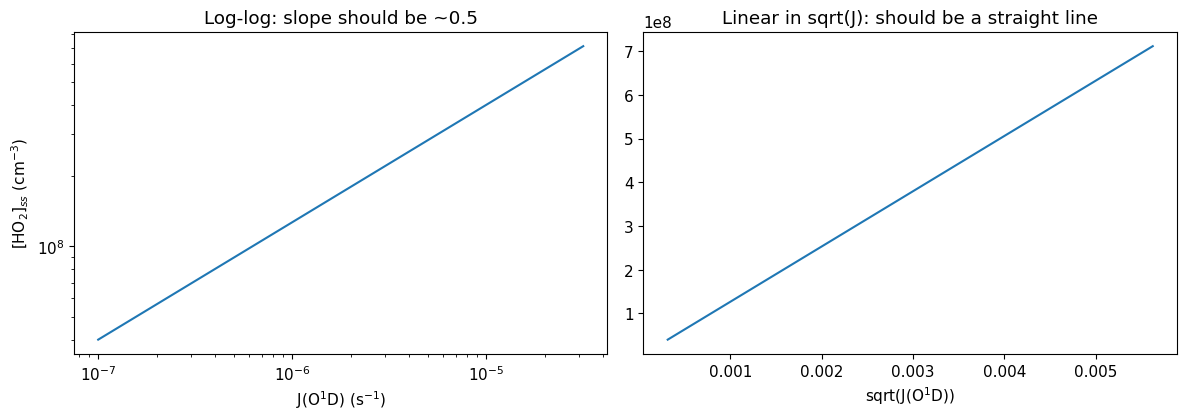

Fitted log-log slope = 0.500 (expect ~0.5, confirming the sqrt dependence)


In [4]:
J_range = np.logspace(-7, -4.5, 40)
HO2_vals = [steady_state_OH_HO2(J, O3_ppb=40, CO_ppb=75)[3] for J in J_range]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].loglog(J_range, HO2_vals)
axes[0].set_xlabel('J(O$^1$D) (s$^{-1}$)')
axes[0].set_ylabel('[HO$_2$]$_{ss}$ (cm$^{-3}$)')
axes[0].set_title('Log-log: slope should be ~0.5')

axes[1].plot(np.sqrt(J_range), HO2_vals)
axes[1].set_xlabel('sqrt(J(O$^1$D))')
axes[1].set_title('Linear in sqrt(J): should be a straight line')
plt.tight_layout()
plt.show()

# Confirm the log-log slope numerically
slope = np.polyfit(np.log(J_range), np.log(HO2_vals), 1)[0]
print(f"Fitted log-log slope = {slope:.3f} (expect ~0.5, confirming the sqrt dependence)")

## Exercises

1. **Sensitivity ranking.** Of J(O1D), [O3], [CO], and f_H2O, which single parameter moves
   [OH]_ss the most for a +50% perturbation from the mid-latitude baseline? Which moves [HO2]_ss
   the most? (Compute each partial sensitivity numerically.)

2. **HO2/OH ratio.** Compute [HO2]/[OH] for the mid-latitude and tropical scenarios above, and
   compare to the interconversion-reaction estimate $k_{2.10}[O_3] = k_{2.7}[OH][CO]/[HO_2]$-style
   reasoning in the notes. Does the ratio move in the direction you'd expect between the two
   regimes?

3. **Trace gas lifetimes.** Using Table 2.2's rate coefficients and a fixed [OH] = 1×10^6 cm^-3,
   compute lifetimes for each listed species and reproduce the "Atmospheric lifetime" column.
   Then recompute using your tropical-scenario [OH] instead -- how much shorter do lifetimes get
   in a higher-OH environment?

4. **Full time-dependent HOx.** Extend the steady-state picture into a short time-dependent ODE
   model for [OH] and [HO2] (using R2.6-R2.11 directly, with a diurnal J(O1D) that switches off
   at night, similar to Module 2's diurnal exercise). Does [OH] reach the same steady value each
   midday, and how quickly does it decay after sunset?